## Step 1. Imports, configuration and data loading

In [1]:
from pathlib import Path
from typing import Final

import joblib
import pandas as pd
import sklearn
from sklearn.base import BaseEstimator
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score, roc_curve
from sklearn.utils.validation import check_is_fitted

# Display configuration
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Paths and constants. Run this notebook from the notebooks/ folder.
DATA_DIR: Final[Path] = Path("../src/ml_model/data/processed")
TRAIN_PATH: Final[Path] = DATA_DIR / "loans_train.parquet"
TEST_PATH: Final[Path] = DATA_DIR / "loans_test.parquet"
PREPROCESSOR_PATH: Final[Path] = DATA_DIR / "preprocessor.joblib"
TARGET: Final[str] = "is_default"

In [2]:
for path in (TRAIN_PATH, TEST_PATH, PREPROCESSOR_PATH):
    if not path.exists():
        raise FileNotFoundError(
            f"{path.resolve()} not found. Run this notebook from the notebooks/ folder."
        )

train_df: pd.DataFrame = pd.read_parquet(TRAIN_PATH)
test_df: pd.DataFrame = pd.read_parquet(TEST_PATH)
preprocessor: BaseEstimator = joblib.load(PREPROCESSOR_PATH)
check_is_fitted(preprocessor)  # raises NotFittedError if it was saved unfitted

X_train: pd.DataFrame = train_df.drop(columns=[TARGET])
y_train: pd.Series = train_df[TARGET]
X_test: pd.DataFrame = test_df.drop(columns=[TARGET])
y_test: pd.Series = test_df[TARGET]

print(
    f"scikit-learn {sklearn.__version__} | preprocessor: {type(preprocessor).__name__}\n"
)

for name, features, target in (("train", X_train, y_train), ("test", X_test, y_test)):
    print(
        f"{name:<5} X: {features.shape[0]:,} rows x {features.shape[1]} features | "
        f"defaults: {int(target.sum()):,} ({target.mean():.3%}) | "
        f"missing target: {int(target.isna().sum())}"
    )

expected_cols: list[str] = list(getattr(preprocessor, "feature_names_in_", []))
mismatch: list[str] = sorted(set(expected_cols) ^ set(X_train.columns))

print(f"\nTarget left in features:        {TARGET in X_train.columns}")
print(
    f"Train/test columns identical:     {list(X_train.columns) == list(X_test.columns)}"
)
print(f"Mismatch vs preprocessor input:   {mismatch or 'none'}\n")
print(preprocessor)

scikit-learn 1.9.0 | preprocessor: ColumnTransformer

train X: 1,076,280 rows x 13 features | defaults: 214,879 (19.965%) | missing target: 0
test  X: 269,070 rows x 13 features | defaults: 53,720 (19.965%) | missing target: 0

Target left in features:        False
Train/test columns identical:     True
Mismatch vs preprocessor input:   none

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['loan_amnt', 'emp_length', 'annual_inc',
                                  'dti', 'fico_range_low', 'open_acc',
                                  'pub_rec', 'revol_util', 'mort_acc']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(stra

## Step 2. Logistic Regression baseline

In [3]:
from time import perf_counter

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

RANDOM_STATE: Final[int] = 42

# Filled in across Steps 2-4, consumed by the comparison table (Step 5)
# and the ROC overlay (Step 6).
results: dict[str, dict[str, float]] = {}
roc_curves: dict[str, tuple[np.ndarray, np.ndarray]] = {}
fitted_pipelines: dict[str, Pipeline] = {}

In [4]:
log_reg_pipeline: Pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

start = perf_counter()
log_reg_pipeline.fit(X_train, y_train)
fit_seconds = perf_counter() - start

y_proba: np.ndarray = log_reg_pipeline.predict_proba(X_test)[:, 1]
y_pred: np.ndarray = log_reg_pipeline.predict(X_test)

results["LogisticRegression"] = {
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba),
    "f1": f1_score(y_test, y_pred),
    "fit_seconds": fit_seconds,
}
roc_curves["LogisticRegression"] = roc_curve(y_test, y_proba)[:2]
fitted_pipelines["LogisticRegression"] = log_reg_pipeline

print(f"Fit time: {fit_seconds:.1f}s\n")
for metric, value in results["LogisticRegression"].items():
    print(f"{metric:>12}: {value:.4f}")

Fit time: 28.6s

     roc_auc: 0.6866
      pr_auc: 0.3518
          f1: 0.4079
 fit_seconds: 28.5539


## Step 3. Random Forest (bagging)

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline: Pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=16,
                min_samples_leaf=20,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

start = perf_counter()
rf_pipeline.fit(X_train, y_train)
fit_seconds = perf_counter() - start

y_proba = rf_pipeline.predict_proba(X_test)[:, 1]
y_pred = rf_pipeline.predict(X_test)

results["RandomForest"] = {
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba),
    "f1": f1_score(y_test, y_pred),
    "fit_seconds": fit_seconds,
}
roc_curves["RandomForest"] = roc_curve(y_test, y_proba)[:2]
fitted_pipelines["RandomForest"] = rf_pipeline

print(f"Fit time: {fit_seconds:.1f}s\n")
for metric, value in results["RandomForest"].items():
    print(f"{metric:>12}: {value:.4f}")

Fit time: 121.7s

     roc_auc: 0.6936
      pr_auc: 0.3597
          f1: 0.4120
 fit_seconds: 121.6683


## Step 4. LightGBM (gradient boosting)

In [6]:
from lightgbm import LGBMClassifier

lgbm_pipeline: Pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LGBMClassifier(
                n_estimators=500,
                learning_rate=0.05,
                num_leaves=31,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

start = perf_counter()
lgbm_pipeline.fit(X_train, y_train)
fit_seconds = perf_counter() - start

y_proba = lgbm_pipeline.predict_proba(X_test)[:, 1]
y_pred = lgbm_pipeline.predict(X_test)

results["LightGBM"] = {
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba),
    "f1": f1_score(y_test, y_pred),
    "fit_seconds": fit_seconds,
}
roc_curves["LightGBM"] = roc_curve(y_test, y_proba)[:2]
fitted_pipelines["LightGBM"] = lgbm_pipeline

print(f"Fit time: {fit_seconds:.1f}s\n")
for metric, value in results["LightGBM"].items():
    print(f"{metric:>12}: {value:.4f}")

[LightGBM] [Info] Number of positive: 214879, number of negative: 861401
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021246 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1218
[LightGBM] [Info] Number of data points in the train set: 1076280, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Fit time: 11.4s

     roc_auc: 0.6986
      pr_auc: 0.3669
          f1: 0.4168
 fit_seconds: 11.3715


## Step 5. Model comparison table

In [7]:
comparison_table: pd.DataFrame = (
    pd.DataFrame(results)
    .T.rename(
        columns={
            "roc_auc": "ROC-AUC",
            "pr_auc": "PR-AUC",
            "f1": "F1-score",
            "fit_seconds": "Fit time (s)",
        }
    )
    .sort_values("ROC-AUC", ascending=False)
)

baseline_pr_auc: float = y_test.mean()
print(f"No-skill PR-AUC baseline (positive class share): {baseline_pr_auc:.4f}\n")
comparison_table

No-skill PR-AUC baseline (positive class share): 0.1997



,ROC-AUC,PR-AUC,F1-score,Fit time (s)
LightGBM,0.699,0.367,0.417,11.372
RandomForest,0.694,0.360,0.412,121.668
LogisticRegression,0.687,0.352,0.408,28.554


## Step 6. ROC curve comparison (for the thesis)

Saved to: D:\Projects\credit-risk-service\notebooks\figures\roc_curves_benchmark.png


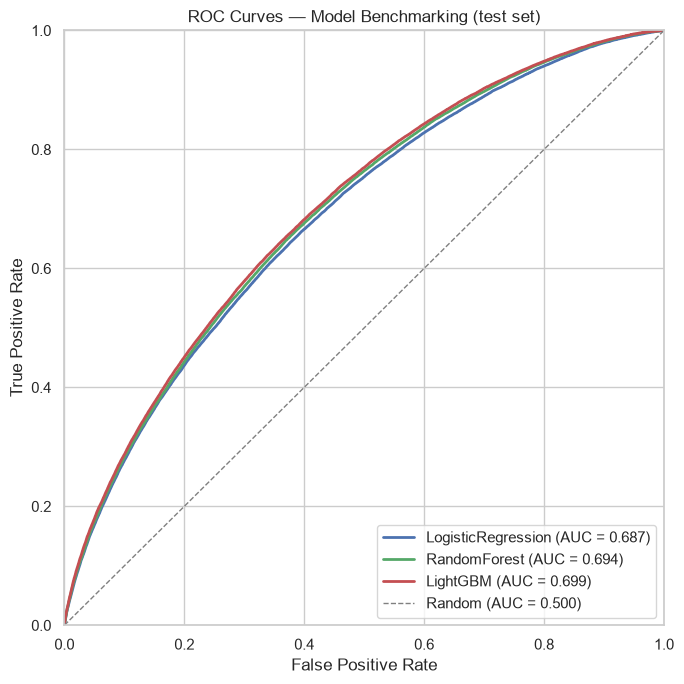

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")  # matches the EDA notebook's style

FIGURES_DIR: Final[Path] = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ROC_PLOT_PATH: Final[Path] = FIGURES_DIR / "roc_curves_benchmark.png"

MODEL_COLORS: Final[dict[str, str]] = {
    "LogisticRegression": "#4C72B0",
    "RandomForest": "#55A868",
    "LightGBM": "#C44E52",
}

fig, ax = plt.subplots(figsize=(7, 7))

for name, (fpr, tpr) in roc_curves.items():
    auc = results[name]["roc_auc"]
    ax.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})",
        color=MODEL_COLORS.get(name),
        linewidth=2,
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1,
    label="Random (AUC = 0.500)",
)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Model Benchmarking (test set)")
ax.legend(loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fig.tight_layout()

fig.savefig(ROC_PLOT_PATH, dpi=300, bbox_inches="tight")
print(f"Saved to: {ROC_PLOT_PATH.resolve()}")
plt.show()

## Step 7. Select best model and save the scoring pipeline

In [9]:
SCORING_PIPELINE_PATH: Final[Path] = Path("../src/ml_model/scoring_pipeline.pkl")

best_model_name: Final[str] = comparison_table.index[
    0
]  # already sorted by ROC-AUC, descending
best_pipeline: Pipeline = fitted_pipelines[best_model_name]

if SCORING_PIPELINE_PATH.exists():
    print(f"Overwriting existing artifact: {SCORING_PIPELINE_PATH.resolve()}\n")

joblib.dump(best_pipeline, SCORING_PIPELINE_PATH)

print(f"Selected model: {best_model_name}")
print(f"Saved to:       {SCORING_PIPELINE_PATH.resolve()}")
print(f"scikit-learn:   {sklearn.__version__} (record this in the PR / CHANGELOG)")
print("\nTest-set metrics for the saved pipeline (from Step 5):")
for metric, value in results[best_model_name].items():
    print(f"{metric:>12}: {value:.4f}")

Overwriting existing artifact: D:\Projects\credit-risk-service\src\ml_model\scoring_pipeline.pkl

Selected model: LightGBM
Saved to:       D:\Projects\credit-risk-service\src\ml_model\scoring_pipeline.pkl
scikit-learn:   1.9.0 (record this in the PR / CHANGELOG)

Test-set metrics for the saved pipeline (from Step 5):
     roc_auc: 0.6986
      pr_auc: 0.3669
          f1: 0.4168
 fit_seconds: 11.3715


## Step 8. Verify the saved pipeline reloads correctly

In [10]:
reloaded_pipeline: Pipeline = joblib.load(SCORING_PIPELINE_PATH)

print(f"Reloaded object type: {type(reloaded_pipeline).__name__}")
print(f"Pipeline steps:       {[name for name, _ in reloaded_pipeline.steps]}\n")

# Same 5 raw feature rows through both objects, the way the FastAPI
# service will eventually call predict_proba on a parsed request.
sample: pd.DataFrame = X_test.head(5)
reloaded_proba: np.ndarray = reloaded_pipeline.predict_proba(sample)[:, 1]
original_proba: np.ndarray = best_pipeline.predict_proba(sample)[:, 1]

print("predict_proba on 5 sample rows:")
print(f"  reloaded:  {np.round(reloaded_proba, 6)}")
print(f"  original:  {np.round(original_proba, 6)}")
print(f"  identical: {np.allclose(reloaded_proba, original_proba)}\n")

full_reloaded_proba: np.ndarray = reloaded_pipeline.predict_proba(X_test)[:, 1]
in_unit_interval: bool = bool(
    ((full_reloaded_proba >= 0) & (full_reloaded_proba <= 1)).all()
)
roc_auc_matches: bool = np.isclose(
    roc_auc_score(y_test, full_reloaded_proba), results[best_model_name]["roc_auc"]
)

print(f"All probabilities in [0, 1]:              {in_unit_interval}")
print(f"Full test-set ROC-AUC matches Step 5:     {roc_auc_matches}")

Reloaded object type: Pipeline
Pipeline steps:       ['preprocessor', 'classifier']

predict_proba on 5 sample rows:
  reloaded:  [0.141659 0.193627 0.224007 0.251519 0.353627]
  original:  [0.141659 0.193627 0.224007 0.251519 0.353627]
  identical: True

All probabilities in [0, 1]:              True
Full test-set ROC-AUC matches Step 5:     True
